In [4]:
%pip install cmocean

# Cell A ? Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cmocean
import json
from pathlib import Path

# Match Figure 6 v2 colormap exactly.
matter_cmap = cmocean.cm.matter


  Using cached cmocean-4.0.3-py3-none-any.whl.metadata (4.2 kB)
Using cached cmocean-4.0.3-py3-none-any.whl (421 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
# === USER PARAMETERS ===

# Water / transport
T_C = 20.0       # °C (doc only unless you add T-dependent props)
rho_w = 1000.0    # kg/m^3
mu = 1.002e-3    # Pa·s
D = 5e-10        # m^2/s (editable)
U = 0.05         # m/s (editable)

# Solid
rho_s = 1300.0   # kg/m^3 (editable)

# Particle
d_p = (212e-6+500e-6)/2     # m

# Fixed values for the two panels
# Ksw is read from the archived WMCR optimization for 20C, medium-size TWP.
# Use the median across saved valid clusters, consistent with the Figure 5 parameter summary.
ksw_spec_path = Path("./output/optimization_specs_PPDQ_20C_M.json")
with open(ksw_spec_path, "r") as f:
    ksw_specs = json.load(f)
ksw_clusters = ksw_specs["all_clusters"]
Ksw_fixed = float(np.median([cluster["Ksw"] for cluster in ksw_clusters]))
print(f"Ksw_fixed from {ksw_spec_path}: {Ksw_fixed:.2f} (median of {len(ksw_clusters)} archived clusters)")

cTWP_fixed_mgL = 0.1
mgL_to_kgm3 = 1e-3
cTWP_fixed = cTWP_fixed_mgL * mgL_to_kgm3

# Present-experiment c_TWP range for panel (a): pore-water volume to total flushed volume.
# The total flushing volume follows the same MPT/Q integration used for the flushing-round update.
twp_mass_mg = 500.0
Vw_mL = 38.33
mpt_days = np.loadtxt('./data/MPT.csv', delimiter=',')
interval_end_days = np.empty_like(mpt_days, dtype=float)
previous_end_day = 0.0
for i, midpoint_day in enumerate(mpt_days):
    interval_end_days[i] = 2 * midpoint_day - previous_end_day
    previous_end_day = interval_end_days[i]
interval_days = np.diff(interval_end_days, prepend=0.0)
interval_minutes = interval_days * 24 * 60
q_20c_m_mL_min = np.genfromtxt('./data/Q_20C_M.csv', delimiter=',')
if q_20c_m_mL_min.ndim == 1:
    q_20c_m_mL_min = q_20c_m_mL_min[:, np.newaxis]
total_flushing_volume_mL = float(np.nanmean(np.cumsum(q_20c_m_mL_min * interval_minutes[:, np.newaxis], axis=0)[-1]))
cTWP_pore_water_mgL = twp_mass_mg / (Vw_mL / 1000)
cTWP_total_flushing_mgL = twp_mass_mg / (total_flushing_volume_mL / 1000)
print(
    f'Present-experiment c_TWP range: {cTWP_pore_water_mgL:.1f} mg/L '
    f'(pore-water) -> {cTWP_total_flushing_mgL:.1f} mg/L '
    f'(total flushing, {total_flushing_volume_mL:.1f} mL)'
)

# Sensitivity ranges (log-spaced)
Ksw_min, Ksw_max = 1000, 100000
n_Ksw = 140
Ksw_grid = np.logspace(np.log10(Ksw_min), np.log10(Ksw_max), n_Ksw)

cTWP_mgL_min, cTWP_mgL_max = 1e-5, 1e5   # mg/L
n_cTWP = 140
cTWP_mgL_grid = np.logspace(np.log10(cTWP_mgL_min), np.log10(cTWP_mgL_max), n_cTWP)
cTWP_grid = cTWP_mgL_grid * mgL_to_kgm3   # kg/m^3

# Time array
t_min_s = 10*60.0             # 10 minutes
t_max_s = 100*24*3600.0       # 100 days
n_t = 420
t = np.logspace(np.log10(t_min_s), np.log10(t_max_s), n_t)

# X-axis ticks (ONLY these labels)
tick_s = [3600, 86400, 7*86400, 30*86400]
tick_lbl = ["1 hour", "1 day", "1 week", "1 month"]

# Colormap settings
vmin, vmax = 0, 1
cf_levels = np.linspace(0, 1, 21)  # for contourf if used

# Optional override
kappa_override = None

Ksw_fixed from output\optimization_specs_PPDQ_20C_M.json: 25203.43 (median of 100 archived clusters)
Present-experiment c_TWP range: 13044.6 mg/L (pore-water) -> 75.5 mg/L (total flushing, 6620.8 mL)


In [6]:
# Cell C — Helper functions

def froessling_k(dp, U, rho_w, mu, D):
    """
    Compute mass transfer coefficient using Frössling correlation for spheres.
    
    Sh = 2 + 0.6*Re^(1/2)*Sc^(1/3)
    where Re = rho_w*U*dp/mu, Sc = mu/(rho_w*D), k = Sh*D/dp
    
    Returns: (k, Re, Sc, Sh)
    """
    Re = rho_w * U * dp / mu
    Sc = mu / (rho_w * D)
    Sh = 2.0 + 0.6 * (Re**0.5) * (Sc**(1.0/3.0))
    k = Sh * D / dp
    return k, Re, Sc, Sh


def kappa_from_k(k, dp):
    """
    Compute kappa = k * (A_p/V_p) = k * (6/dp) for a sphere.
    
    Returns: kappa (1/s)
    """
    return k * 6.0 / dp


def cfhat_grid_time(t, alpha, kappa):
    """
    Compute normalized free fraction cf_hat = c_f/c_tot over a grid.
    
    Parameters:
    - t: time array, shape (1, n_t) or (n_t,)
    - alpha: shape (n_param, 1) or scalar
    - kappa: scalar (1/s)
    
    Returns:
    - cf_hat: shape (n_param, n_t) via broadcasting
    
    Formula:
    tau = 1/(kappa*alpha)
    cf_hat_star = 1/(1 + Ksw*cTWP/rho_s)  # computed outside or passed in
    cf_hat = cf_hat_star * (1 - exp(-t/tau))
    
    Note: This function assumes cf_hat_star is already factored into the calculation
    or computed separately. For modularity, we compute tau here and return the exponential part.
    """
    tau = 1.0 / (kappa * alpha)
    cf_hat = 1.0 - np.exp(-t / tau)
    return cf_hat


def half_life(alpha, kappa):
    """
    Compute half-life: t_1/2 = ln(2)/(kappa*alpha)
    
    Parameters:
    - alpha: array or scalar
    - kappa: scalar (1/s)
    
    Returns:
    - t_half: time to reach 50% of asymptote
    """
    return np.log(2.0) / (kappa * alpha)

In [7]:
# Cell D — Compute k, kappa, print diagnostics

k, Re, Sc, Sh = froessling_k(d_p, U, rho_w, mu, D)
kappa_computed = kappa_from_k(k, d_p)

# Calculate chi factor from lab measurement (computed in Cell F)
# This will be updated after Cell F runs
chi_factor = 0.3916  # Default value, will be overwritten

if kappa_override is not None:
    kappa = kappa_override
    print(f"Using kappa_override = {kappa:.6e} 1/s")
else:
    kappa = kappa_computed * chi_factor
    print(f"Using computed kappa with chi factor = {kappa:.6e} 1/s")

print(f"\n=== Diagnostics ===")
print(f"Re (Reynolds number) = {Re:.4f}")
print(f"Sc (Schmidt number)  = {Sc:.4f}")
print(f"Sh (Sherwood number) = {Sh:.4f}")
print(f"k (mass transfer coeff) = {k:.6e} m/s")
print(f"A_p/V_p = 6/d_p = {6.0/d_p:.2e} 1/m")
print(f"kappa (base) = k*(A_p/V_p) = {kappa_computed:.6e} 1/s")
print(f"chi factor = {chi_factor:.4f}")
print(f"kappa (with chi) = {kappa:.6e} 1/s")

Using computed kappa with chi factor = 3.140845e-01 1/s

=== Diagnostics ===
Re (Reynolds number) = 17.7645
Sc (Schmidt number)  = 2004.0000
Sh (Sherwood number) = 33.8831
k (mass transfer coeff) = 4.758856e-05 m/s
A_p/V_p = 6/d_p = 1.69e+04 1/m
kappa (base) = k*(A_p/V_p) = 8.020544e-01 1/s
chi factor = 0.3916
kappa (with chi) = 3.140845e-01 1/s


In [8]:
# Cell F — Calculate k*A for given particle mass and estimate chi factor

# Given parameters
mass_particle = 0.5  # g
rho_particle = 1.3   # g/cm³
k_A_lab_mL_day = 5889.24  # mL/day (lab measurement)

# Convert density to kg/m³ for consistency
rho_particle_SI = rho_particle * 1000  # kg/m³

# Calculate volume of particles
volume_particle = mass_particle / rho_particle  # cm³
volume_particle_m3 = volume_particle * 1e-6  # m³

# Calculate number of particles (assuming spherical particles)
volume_single_particle = (np.pi / 6) * (d_p**3)  # m³
n_particles = volume_particle_m3 / volume_single_particle

# Calculate total surface area
area_single_particle = np.pi * (d_p**2)  # m²
total_area = n_particles * area_single_particle  # m²

# Calculate theoretical k*A (without chi factor)
k_A_theoretical = k * total_area  # m³/s
k_A_theoretical_mL_day = k_A_theoretical * 1e6 * 86400  # mL/day

# Calculate chi factor from lab measurement
k_A_lab_m3_s = k_A_lab_mL_day / (1e6 * 86400)  # Convert to m³/s
chi_factor = k_A_lab_m3_s / k_A_theoretical

print(f"\n=== k*A Calculation ===")
print(f"Mass of particles: {mass_particle} g")
print(f"Particle density: {rho_particle} g/cm³")
print(f"Particle diameter: {d_p*1e6} μm")
print(f"Volume of particles: {volume_particle:.4f} cm³")
print(f"Number of particles: {n_particles:.2e}")
print(f"Total surface area: {total_area:.4e} m²")
print(f"k (mass transfer coeff): {k:.6e} m/s")
print(f"\nTheoretical k*A = {k_A_theoretical:.6e} m³/s")
print(f"Theoretical k*A = {k_A_theoretical_mL_day:.4f} mL/day")
print(f"\nLab measured k*A = {k_A_lab_mL_day:.4f} mL/day")
print(f"\n*** Chi factor (χ) = {chi_factor:.4f} ***")
print(f"    (Ratio of lab measurement to theoretical prediction)")
print(f"    χ represents effective surface contact efficiency")


=== k*A Calculation ===
Mass of particles: 0.5 g
Particle density: 1.3 g/cm³
Particle diameter: 356.0 μm
Volume of particles: 0.3846 cm³
Number of particles: 1.63e+04
Total surface area: 6.4823e-03 m²
k (mass transfer coeff): 4.758856e-05 m/s

Theoretical k*A = 3.084825e-07 m³/s
Theoretical k*A = 26652.8863 mL/day

Lab measured k*A = 5889.2400 mL/day

*** Chi factor (χ) = 0.2210 ***
    (Ratio of lab measurement to theoretical prediction)
    χ represents effective surface contact efficiency



Figure saved as: Figure_6.png


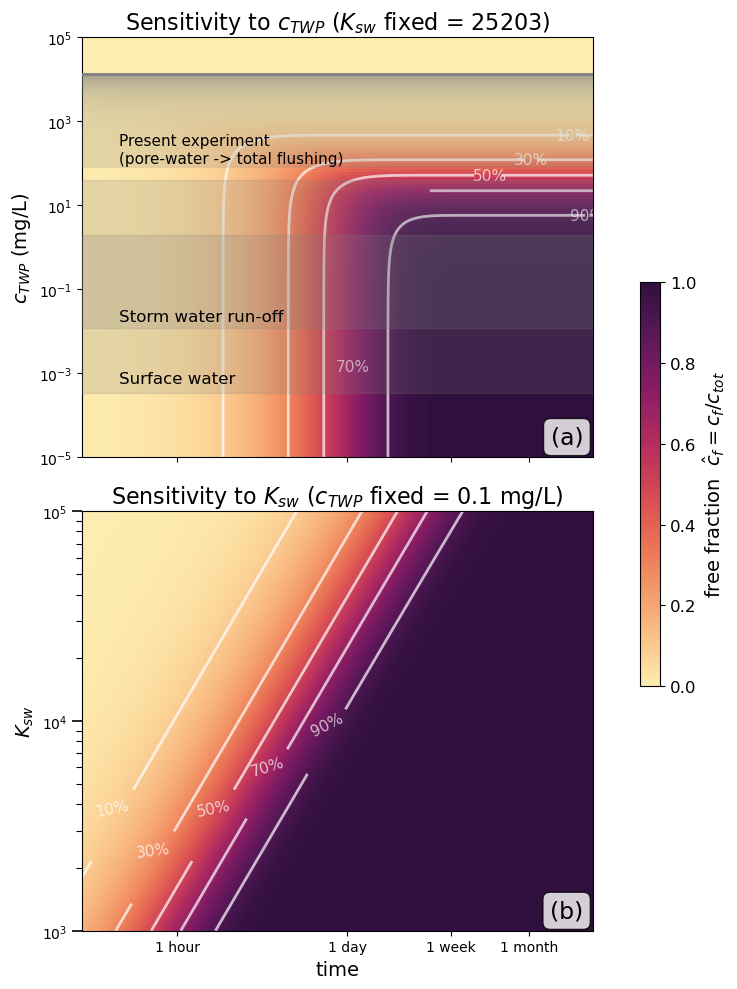

In [9]:
# Cell E — Build 2-panel contour figure (main deliverable)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 1, figsize=(6.8, 10), sharex=True)
ax_top = axes[0]
ax_bot = axes[1]

# ========== TOP PANEL: cTWP sensitivity (Ksw fixed) ==========
# Broadcast arrays
CT = cTWP_grid[:, None]         # shape (n_cTWP, 1)
TT = t[None, :]                 # shape (1, n_t)

# Compute analytical solution
alpha_top = 1.0/Ksw_fixed + CT/rho_s
cf_hat_star_top = 1.0/(1.0 + Ksw_fixed*CT/rho_s)
tau_top = 1.0/(kappa*alpha_top)
cf_hat_top = cf_hat_star_top * (1.0 - np.exp(-TT/tau_top))

# Plot heatmap (use mg/L for y-axis)
cTWP_mgL_mesh = cTWP_mgL_grid[:, None]
im_top = ax_top.pcolormesh(TT, cTWP_mgL_mesh, cf_hat_top, shading="auto", vmin=vmin, vmax=vmax, cmap=matter_cmap)

# Add contour lines at 10%, 30%, 50%, 70%, 90%
# Create meshgrid for contour (needs 2D arrays)
TT_mesh, cTWP_mgL_mesh2 = np.meshgrid(t, cTWP_mgL_grid)
contour_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
cs_top = ax_top.contour(TT_mesh, cTWP_mgL_mesh2, cf_hat_top, levels=contour_levels, colors='white', linewidths=2.0, alpha=0.7)
# Create manual labels with percentage formatting
fmt_dict = {0.1: '10%', 0.3: '30%', 0.5: '50%', 0.7: '70%', 0.9: '90%'}
ax_top.clabel(cs_top, inline=True, fontsize=11, fmt=fmt_dict, inline_spacing=1.5)

# Add horizontal bands for water type ranges (plot after contours)
# Band 1: Surface water (0.00034 to 1.99 mg/L)
ax_top.axhspan(0.00034, 1.99, alpha=0.2, color='grey', zorder=10)
ax_top.text(t_min_s * 2, 0.0005, 'Surface water', fontsize=12, color='black', 
            verticalalignment='bottom', horizontalalignment='left', zorder=11)

# Band 2: Storm water run-off (0.012 to 40.8 mg/L)
ax_top.axhspan(0.012, 40.8, alpha=0.2, color='grey', zorder=10)
ax_top.text(t_min_s * 2, 0.015, 'Storm water run-off', fontsize=12, color='black',
            verticalalignment='bottom', horizontalalignment='left', zorder=11)

# Present experiment: solid pore-water boundary plus fading range down to total flushing volume.
present_high_mgL = min(cTWP_pore_water_mgL, cTWP_mgL_max)
present_low_mgL = max(cTWP_total_flushing_mgL, cTWP_mgL_min)
present_gradient = np.ones((256, 2, 4))
present_gradient[..., :3] = 0.50  # grey
present_gradient[..., 3] = np.linspace(0.20, 0.72, 256)[:, None]
ax_top.imshow(
    present_gradient,
    extent=[t_min_s, t_max_s, present_low_mgL, present_high_mgL],
    origin='lower',
    aspect='auto',
    interpolation='bicubic',
    zorder=10,
)
ax_top.axhline(y=present_high_mgL, color='grey', linestyle='-', linewidth=2, zorder=11)
ax_top.text(
    t_min_s * 2, present_low_mgL * 1.15,
    'Present experiment\n(pore-water -> total flushing)',
    fontsize=11, color='black',
    verticalalignment='bottom', horizontalalignment='left', zorder=12,
)

# Set scales and labels
ax_top.set_xscale("log")
ax_top.set_yscale("log")
ax_top.set_ylabel(r"$c_{TWP}$ (mg/L)", fontsize=14)
ax_top.set_title(f"Sensitivity to $c_{{TWP}}$ ($K_{{sw}}$ fixed = {Ksw_fixed:.0f})", fontsize=16)
ax_top.set_xlim(t_min_s, t_max_s)
ax_top.set_ylim(cTWP_mgL_min, cTWP_mgL_max)

# Set x-ticks
ax_top.set_xticks(tick_s)
ax_top.set_xticklabels(tick_lbl)

# Remove minor x-ticks
ax_top.xaxis.set_minor_locator(mticker.NullLocator())
ax_top.tick_params(axis="x", which="minor", bottom=False)

# Add panel label (a) at bottom right
ax_top.text(0.98, 0.02, '(a)', transform=ax_top.transAxes, fontsize=17, 
            verticalalignment='bottom', horizontalalignment='right', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ========== BOTTOM PANEL: Ksw sensitivity (cTWP fixed) ==========
# Broadcast arrays
KSW = Ksw_grid[:, None]         # shape (n_Ksw, 1)
TT = t[None, :]                 # shape (1, n_t)

# Compute analytical solution
alpha_bot = 1.0/KSW + cTWP_fixed/rho_s
cf_hat_star_bot = 1.0/(1.0 + KSW*cTWP_fixed/rho_s)
tau_bot = 1.0/(kappa*alpha_bot)
cf_hat_bot = cf_hat_star_bot * (1.0 - np.exp(-TT/tau_bot))

# Plot heatmap
im_bot = ax_bot.pcolormesh(TT, KSW, cf_hat_bot, shading="auto", vmin=vmin, vmax=vmax, cmap=matter_cmap)

# Add contour lines at 10%, 30%, 50%, 70%, 90%
# Create meshgrid for contour (needs 2D arrays)
TT_mesh2, KSW_mesh = np.meshgrid(t, Ksw_grid)
contour_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
cs_bot = ax_bot.contour(TT_mesh2, KSW_mesh, cf_hat_bot, levels=contour_levels, colors='white', linewidths=2.0, alpha=0.7)
# Create manual labels with percentage formatting
fmt_dict = {0.1: '10%', 0.3: '30%', 0.5: '50%', 0.7: '70%', 0.9: '90%'}
ax_bot.clabel(cs_bot, inline=True, fontsize=11, fmt=fmt_dict, inline_spacing=5)
# Shift contour labels up by 20% in data (log) space
for txt in cs_bot.labelTexts:
    x, y = txt.get_position()
    txt.set_position((x, y * 1.2))

# Set scales and labels
ax_bot.set_xscale("log")
ax_bot.set_yscale("log")
ax_bot.set_ylabel(r"$K_{sw}$", fontsize=14)
ax_bot.set_xlabel("time", fontsize=14)
ax_bot.set_title(f"Sensitivity to $K_{{sw}}$ ($c_{{TWP}}$ fixed = {cTWP_fixed_mgL} mg/L)", fontsize=16)
ax_bot.set_xlim(t_min_s, t_max_s)

# Y-axis: span 10^3 to 10^5, labeled ticks at integer decades only
ax_bot.set_ylim(1e3, 1e5)
ax_bot.set_yticks([10**3, 10**4, 10**5])
ax_bot.set_yticklabels([r'$10^{3}$', r'$10^{4}$', r'$10^{5}$'])
# Standard log minor ticks (no labels) between the major ticks
ax_bot.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10)))
ax_bot.yaxis.set_minor_formatter(mticker.NullFormatter())
ax_bot.tick_params(axis='y', which='minor', length=4, width=0.8)
ax_bot.tick_params(axis='y', which='major', length=7, width=1.2)

# Set x-ticks
ax_bot.set_xticks(tick_s)
ax_bot.set_xticklabels(tick_lbl)

# Remove minor x-ticks
ax_bot.xaxis.set_minor_locator(mticker.NullLocator())
ax_bot.tick_params(axis="x", which="minor", bottom=False)

# Add panel label (b) at bottom right
ax_bot.text(0.98, 0.02, '(b)', transform=ax_bot.transAxes, fontsize=17, 
            verticalalignment='bottom', horizontalalignment='right', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ========== COLORBAR (shared for both panels) ==========
# Adjust layout first
plt.tight_layout()

# Add colorbar with increased padding to move it to the right
cbar = fig.colorbar(im_bot, ax=[ax_top, ax_bot], label=r"free fraction  $\hat{c}_f = c_f/c_{tot}$", pad=0.08, fraction=0.035)
cbar.ax.tick_params(labelsize=12)
cbar.set_label(r"free fraction  $\hat{c}_f = c_f/c_{tot}$", fontsize=14)

# Save figure
fig.savefig("Figure_6.png", dpi=300, bbox_inches="tight")
print("\nFigure saved as: Figure_6.png")

plt.show()
